# Classifier Training Log Visualization

이 노트북은 `train_classifier.py`에서 저장된 학습 로그(`result/classifier/train_log.npy`)를 시각화합니다.

- Loss와 Accuracy의 변화를 그래프로 확인할 수 있습니다.

In [6]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Load training log data
log_path = '../result/classifier/train_log.npy'
log = np.load(log_path)
epochs = log[:, 0]
train_losses = log[:, 1]
train_accuracies = log[:, 2]
val_losses = log[:, 3]
val_accuracies = log[:, 4]

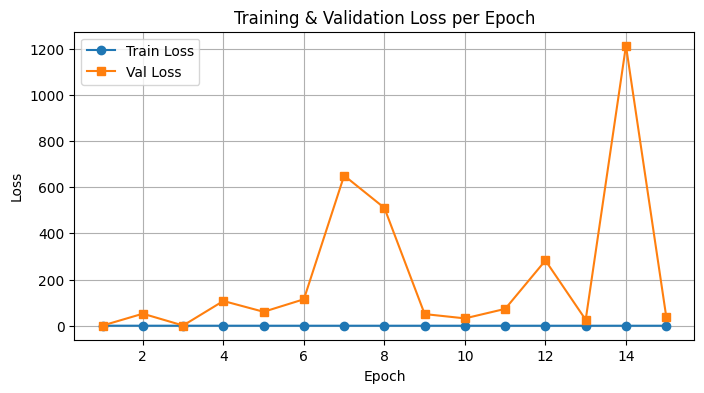

In [9]:
# Visualize training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss per Epoch')
plt.grid(True)
plt.legend()
plt.show()

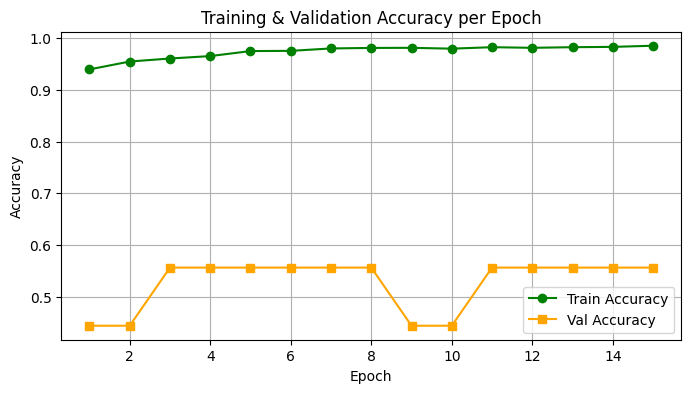

In [10]:
# Visualize training and validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_accuracies, marker='o', color='green', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='s', color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy per Epoch')
plt.grid(True)
plt.legend()
plt.show()

# Misclassified Validation Samples Visualization

아래 셀은 validation set에서 잘못 분류된 MRI 슬라이스를 시각화합니다.
- 실제(label)와 예측(pred)이 다른 샘플만 표시됩니다.
- 각 이미지 아래에 실제/예측 클래스가 함께 표시됩니다.

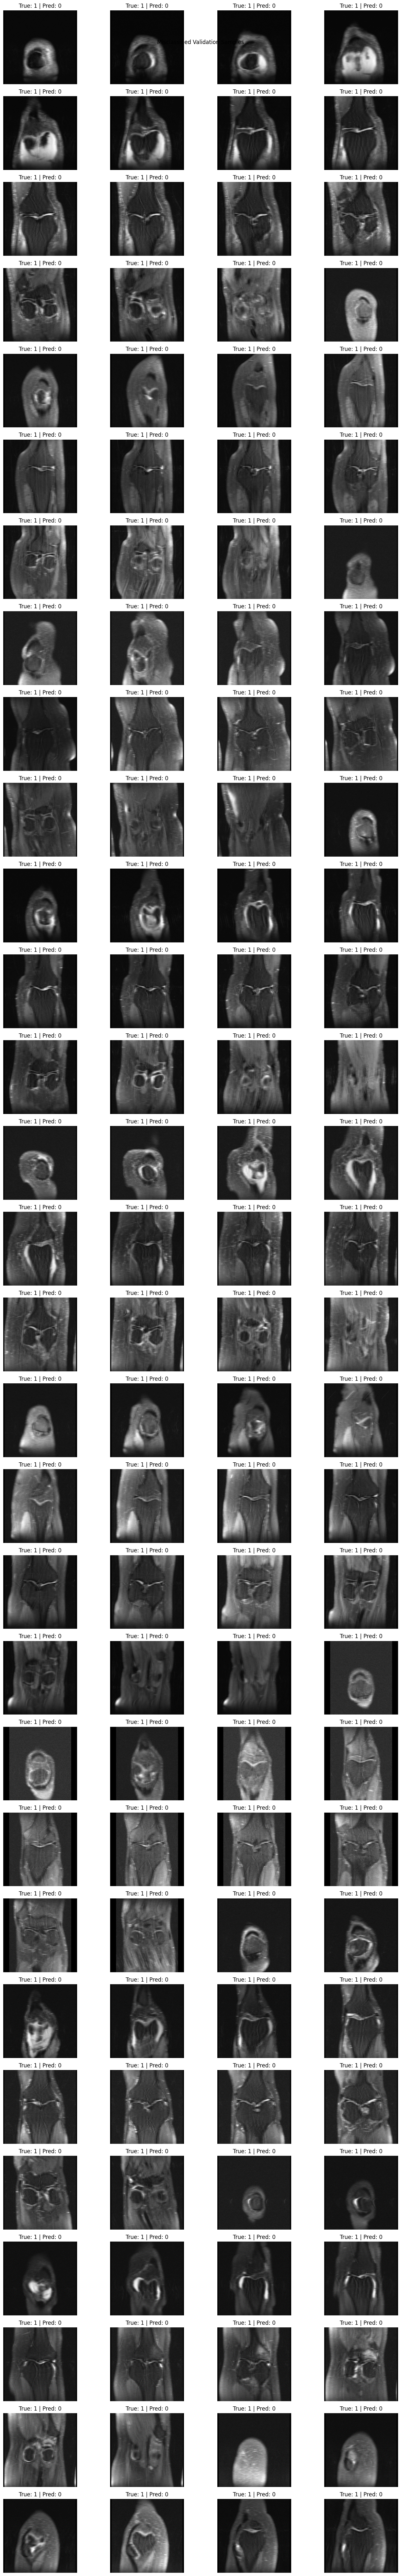

In [14]:
import torch
from utils.model.simple_classifier import SimpleClassifier
from utils.data.load_image_data import load_image_data
from pathlib import Path

# Load model
model_path = '../result/classifier/model.pt'
checkpoint = torch.load(model_path, map_location='cpu')
model = SimpleClassifier()
model.load_state_dict(checkpoint['model'])
model.eval()

# Load val set (batch_size=1 for easy indexing)
val_dir = Path('../Data/val')
val_loader = load_image_data(val_dir, batch_size=1, shuffle=False)

misclassified = []
with torch.no_grad():
    for img, label in val_loader:
        output = model(img)
        pred = output.argmax(1)
        if pred.item() != label.item():
            misclassified.append((img.squeeze(0).squeeze(0).numpy(), label.item(), pred.item()))
        if len(misclassified) >= 120:
            break

# Plot misclassified samples (up to 12)
fig, axes = plt.subplots(30, 4, figsize=(14, 80))
axes = axes.flatten()
for i, (img, label, pred) in enumerate(misclassified):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {label} | Pred: {pred}')
    axes[i].axis('off')
for j in range(len(misclassified), 120):
    axes[j].axis('off')
plt.suptitle('Misclassified Validation Samples')
plt.tight_layout()
plt.show()

In [27]:
# Print filenames and labels from the validation loader
for batch in val_loader:
	if isinstance(batch, dict):
		filenames = batch.get('filename', None)
		labels = batch.get('image_label', None)
	else:
		# If dataset does not provide filenames, only labels are available
		filenames = None
		_, labels = batch
	print(f"Filenames: {filenames}")
	print(f"Labels: {labels}")
	break  # Remove this break if you want to print all batches

Filenames: None
Labels: tensor([0])


In [16]:
# Count misclassified predictions by predicted class over the entire validation set
from collections import Counter
all_misclassified = []
with torch.no_grad():
    for img, label in load_image_data(val_dir, batch_size=1, shuffle=False):
        output = model(img)
        pred = output.argmax(1)
        if pred.item() != label.item():
            all_misclassified.append(pred.item())
pred_counts = Counter(all_misclassified)
print(f"Misclassified samples with pred=0: {pred_counts.get(0, 0)}")
print(f"Misclassified samples with pred=1: {pred_counts.get(1, 0)}")

Misclassified samples with pred=0: 383
Misclassified samples with pred=1: 0


# Misclassified Train Samples Visualization

아래 셀은 train set에서 잘못 분류된 MRI 슬라이스를 시각화합니다.
- 실제(label)와 예측(pred)이 다른 샘플만 표시됩니다.
- 각 이미지 아래에 실제/예측 클래스가 함께 표시됩니다.

[INFO] Misclassified train samples: 2241 / 4937
[INFO] Misclassified count by predicted class: Counter({0: 2241})


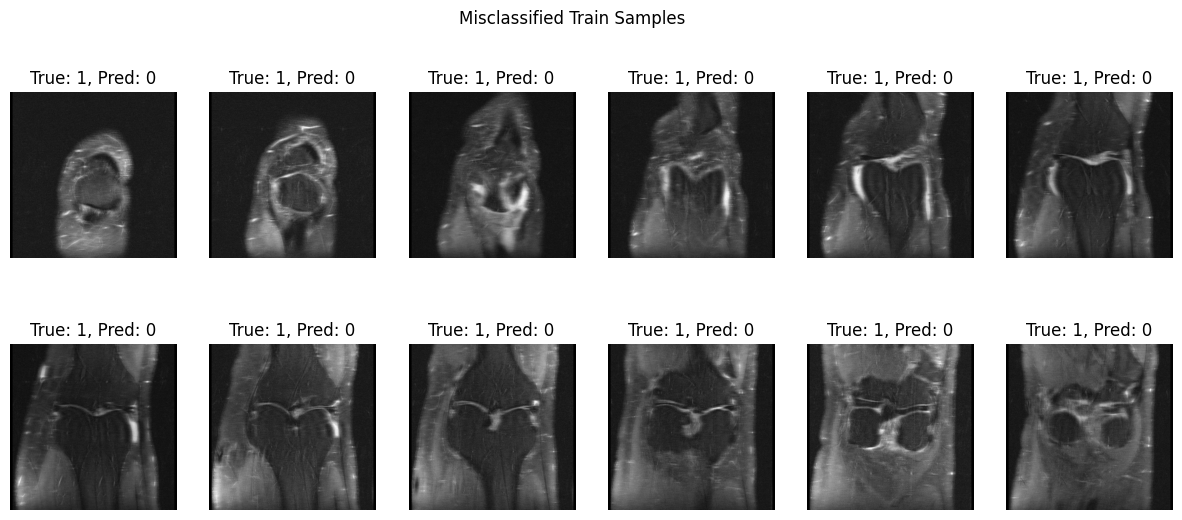

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from utils.data.load_image_data import load_image_data
from utils.model.simple_classifier import SimpleClassifier

# Load model
model_path = '../result/classifier/model.pt'
ckpt = torch.load(model_path, map_location='cpu')
model = SimpleClassifier()
model.load_state_dict(ckpt['model'])
model.eval()

# Load train data
train_dir = '../Data/train'
loader = load_image_data(train_dir, batch_size=32, shuffle=False)

misclassified = []
with torch.no_grad():
    for images, labels in loader:
        outputs = model(images)
        preds = outputs.argmax(1)
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((images[i].cpu(), labels[i].item(), preds[i].item()))

print(f"[INFO] Misclassified train samples: {len(misclassified)} / {len(loader.dataset)}")

# Count by predicted class
if misclassified:
    pred_classes = [p for _, _, p in misclassified]
    print("[INFO] Misclassified count by predicted class:", Counter(pred_classes))
else:
    print("[INFO] No misclassified train samples!")

# Visualize up to 12 misclassified samples
n_show = min(12, len(misclassified))
plt.figure(figsize=(15, 6))
for idx in range(n_show):
    img, label, pred = misclassified[idx]
    # If image is (1, H, W), squeeze channel
    img = img.squeeze().numpy()
    plt.subplot(2, 6, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'True: {label}, Pred: {pred}')
    plt.axis('off')
plt.suptitle('Misclassified Train Samples')
plt.show()

In [18]:
# 디버깅: 첫 train 배치의 이미지/라벨/모델 출력 shape, 값 확인
import torch
from utils.model.simple_classifier import SimpleClassifier
from utils.data.load_image_data import load_image_data

model_path = '../result/classifier/model.pt'
ckpt = torch.load(model_path, map_location='cpu')
model = SimpleClassifier()
model.load_state_dict(ckpt['model'])
model.eval()

train_dir = '../Data/train'
loader = load_image_data(train_dir, batch_size=8, shuffle=True)

for i, batch in enumerate(loader):
    # batch가 dict인지 tuple인지 확인
    if isinstance(batch, dict):
        images = batch['kspace']
        labels = batch['image_label']
    else:
        images, labels = batch
    print(f"[DEBUG] images shape: {images.shape}, labels shape: {labels.shape}, labels dtype: {labels.dtype}")
    outputs = model(images)
    print(f"[DEBUG] outputs shape: {outputs.shape}, outputs sample: {outputs[0].detach().cpu().numpy()}")
    preds = outputs.argmax(1)
    print(f"[DEBUG] preds: {preds.cpu().numpy()}, labels: {labels.cpu().numpy()}")
    break

[DEBUG] images shape: torch.Size([8, 1, 384, 384]), labels shape: torch.Size([8]), labels dtype: torch.int64
[DEBUG] outputs shape: torch.Size([8, 2]), outputs sample: [  8.7103   -11.695296]
[DEBUG] preds: [0 0 0 0 0 0 0 0], labels: [0 0 1 0 0 1 0 1]
